#1: Imports and Path Setup

In [5]:
import os
import sys
import json
import csv
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime

import subprocess
import psutil


In [2]:
PROJECT_ROOT = '/content/drive/MyDrive/Transformer_Mine'
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'figures')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
EXPERIMENTS_CSV = os.path.join(PROJECT_ROOT, 'experiments/results.csv')

In [3]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Transformer_Mine

Mounted at /content/drive
/content/drive/MyDrive/Transformer_Mine


In [4]:


print("TensorFlow:", tf.__version__)
print("Project root:", PROJECT_ROOT)
print("Date:", datetime.now().strftime("%Y-%m-%d %H:%M"))

TensorFlow: 2.20.0
Project root: /content/drive/MyDrive/Transformer_Mine
Date: 2026-09-30 04:32


#2: System and Hardware Summary

In [6]:
def get_gpu_info():
    try:
        result = subprocess.run(
            ['nvidia-smi',
             '--query-gpu=name,memory.total,memory.used',
             '--format=csv,noheader,nounits'],
            capture_output=True, text=True
        )
        parts = result.stdout.strip().split(', ')
        return {
            'name'     : parts[0],
            'total_mb' : int(parts[1]),
            'used_mb'  : int(parts[2]),
        }
    except Exception as e:
        return {'error': str(e)}

In [7]:
gpu = get_gpu_info()
ram = psutil.virtual_memory()
disk = psutil.disk_usage('/content')

In [8]:
print("COMPUTATIONAL ENVIRONMENT")
print("=" * 55)
print(f"  Platform       : Google Colab")
print(f"  TensorFlow     : {tf.__version__}")
print(f"  Python         : {sys.version.split()[0]}")
print()
if 'error' not in gpu:
    print(f"  GPU            : {gpu['name']}")
    print(f"  GPU VRAM       : {gpu['total_mb']:,} MB total  "
          f"{gpu['used_mb']:,} MB used")
else:
    print(f"  GPU            : not available")
print(f"  RAM            : {ram.total/1e9:.1f} GB total  "
      f"{ram.used/1e9:.1f} GB used")
print(f"  Disk           : {disk.total/1e9:.0f} GB total  "
      f"{disk.free/1e9:.1f} GB free")
print()
print("  Original paper hardware:")
print("  8x NVIDIA P100 GPU, 12h training")
print()
print("  Our hardware:")
print("  1x Colab GPU (shared), ~35 min training")

COMPUTATIONAL ENVIRONMENT
  Platform       : Google Colab
  TensorFlow     : 2.20.0
  Python         : 3.13.15

  GPU            : not available
  RAM            : 13.6 GB total  1.3 GB used
  Disk           : 116 GB total  93.7 GB free

  Original paper hardware:
  8x NVIDIA P100 GPU, 12h training

  Our hardware:
  1x Colab GPU (shared), ~35 min training


#3: Model Configuration Comparison

In [9]:
print("MODEL CONFIGURATION")
configs = [
    ("Parameter", "Original Paper", "Our Implementation"),
    ("-" * 22, "-" * 18, "-" * 20),
    ("Architecture", "Transformer Base", "Transformer Base"),
    ("Encoder layers", "6", "6 (defined)"),
    ("Decoder layers", "6", "6 (defined)"),
    ("d_model", "512", "512 (defined)"),
    ("num_heads", "8", "8 (defined)"),
    ("d_k = d_v", "64", "64 (verified)"),
    ("d_ff", "2048", "2048 (defined)"),
    ("dropout", "0.1", "0.1"),
    ("label smoothing", "0.1", "0.1"),
    ("positional enc", "sinusoidal", "sinusoidal (exact)"),
    ("weight tying", "yes", "yes (TiedTransformer)"),
    ("attention", "scaled dot-product", "from scratch (no MHA layer)"),
    ("normalization", "POST-LN", "POST-LN"),
    ("optimizer", "Adam", "Adam"),
    ("beta_1", "0.9", "0.9"),
    ("beta_2", "0.98", "0.98"),
    ("epsilon", "1e-9", "1e-9"),
    ("warmup steps", "4000", "4000 (full scale)"),
    ("LR schedule", "paper formula", "exact paper formula"),
    ("beam size", "4", "4"),
    ("length penalty", "alpha=0.6", "alpha=0.6"),
    ("-" * 22, "-" * 18, "-" * 20),
    ("Deviations", "", "none in architecture"),
]

for row in configs:
    print(f"  {row[0]:<24} {row[1]:<20} {row[2]}")

print()
print("  COLAB-SCALE experiment (Phase 13):")
print("    num_layers=3, d_model=256, num_heads=4, d_ff=1024")
print("    Explicitly labelled — not paper reproduction")

MODEL CONFIGURATION
  Parameter                Original Paper       Our Implementation
  ----------------------   ------------------   --------------------
  Architecture             Transformer Base     Transformer Base
  Encoder layers           6                    6 (defined)
  Decoder layers           6                    6 (defined)
  d_model                  512                  512 (defined)
  num_heads                8                    8 (defined)
  d_k = d_v                64                   64 (verified)
  d_ff                     2048                 2048 (defined)
  dropout                  0.1                  0.1
  label smoothing          0.1                  0.1
  positional enc           sinusoidal           sinusoidal (exact)
  weight tying             yes                  yes (TiedTransformer)
  attention                scaled dot-product   from scratch (no MHA layer)
  normalization            POST-LN              POST-LN
  optimizer                Adam        

#4: Training Results Summary

In [10]:
print("TRAINING RESULTS")

colab_results = {
    'model' : 'COLAB-SCALE (3L, d256, h4, ff1024)',
    'dataset' : 'Tatoeba EN-DE (~80k pairs)',
    'steps' : 10000,
    'batch_size' : 64,
    'train_loss_start' : 5.38,
    'train_loss_end' : 2.14,
    'val_loss_end' : 2.63,
    'training_time' : '~35 min (2114s)',
    'parameters' : 9_616_384,
}

print()
print("  COLAB-SCALE Experiment:")
for k, v in colab_results.items():
    print(f"    {k:<22} : {v}")

print()
print("  Training curve summary:")
print("    Steps 1-2000   : rapid decrease (5.38 → 3.30)")
print("    Steps 2000-7000: steady decrease (3.30 → 2.18)")
print("    Steps 7000+    : plateau (~2.14 train, ~2.63 val)")
print()
print("  Session recovery: tested and confirmed working")
print("  Checkpoints    : saved every 1000 steps (.h5 + TF format)")
print()
print("  Paper training (for reference):")
print("    Model          : Transformer Base (6L, d512, h8, ff2048)")
print("    Dataset        : WMT14 EN-DE (~4.5M pairs)")
print("    Steps          : 100,000")
print("    Hardware       : 8x P100 GPU")
print("    Training time  : 12 hours")
print("    Parameters     : ~65M (with vocab_size=37k)")

TRAINING RESULTS

  COLAB-SCALE Experiment:
    model                  : COLAB-SCALE (3L, d256, h4, ff1024)
    dataset                : Tatoeba EN-DE (~80k pairs)
    steps                  : 10000
    batch_size             : 64
    train_loss_start       : 5.38
    train_loss_end         : 2.14
    val_loss_end           : 2.63
    training_time          : ~35 min (2114s)
    parameters             : 9616384

  Training curve summary:
    Steps 1-2000   : rapid decrease (5.38 → 3.30)
    Steps 2000-7000: steady decrease (3.30 → 2.18)
    Steps 7000+    : plateau (~2.14 train, ~2.63 val)

  Session recovery: tested and confirmed working
  Checkpoints    : saved every 1000 steps (.h5 + TF format)

  Paper training (for reference):
    Model          : Transformer Base (6L, d512, h8, ff2048)
    Dataset        : WMT14 EN-DE (~4.5M pairs)
    Steps          : 100,000
    Hardware       : 8x P100 GPU
    Training time  : 12 hours
    Parameters     : ~65M (with vocab_size=37k)


#5: BLEU Results Summary

In [12]:
bleu_path = os.path.join(RESULTS_DIR, 'bleu_small_scale.json')

if os.path.exists(bleu_path):
    with open(bleu_path) as f:
        bleu_data = json.load(f)
    greedy_bleu = bleu_data['greedy']['BLEU']
    beam_bleu   = bleu_data['beam_k4']['BLEU']
else:
    print("BLEU results file not found.")
    print("Run Phase 15 first.")
    greedy_bleu = None
    beam_bleu   = None

print("BLEU EVALUATION RESULTS")
print()
print("  Our results (COLAB-SCALE, Tatoeba val, 500 sentences):")
if greedy_bleu is not None:
    print(f"    Greedy decoding  : {greedy_bleu:.2f} BLEU")
    print(f"    Beam search k=4  : {beam_bleu:.2f} BLEU")
print()
print("  Paper results (Transformer Base, WMT14 newstest2014):")
print("    Beam search k=4  : 27.3 BLEU")
print()
print("  IMPORTANT — these are NOT directly comparable:")
print("    Our eval set : Tatoeba val (short, simple sentences)")
print("    Paper eval   : WMT14 newstest2014 (news domain, harder)")
print()
print("  Short sentences inflate BLEU — 4-grams cover a larger")
print("  fraction of each sentence, raising all precision scores.")
print()
print("  A fair comparison requires:")
print("    1. WMT14 EN-DE training data")
print("    2. newstest2014 as the test set")
print("    3. Transformer Base configuration (6L d512)")
print("    4. Sufficient compute (multiple GPUs, 100k+ steps)")

print()
print("  Greedy vs Beam search:")
if greedy_bleu is not None and beam_bleu is not None:
    diff = beam_bleu - greedy_bleu
    print(f"    Difference : {diff:+.2f} BLEU")
    if greedy_bleu > beam_bleu:
        print("    Greedy outperforms beam on short Tatoeba sentences.")
        print("    Beam search benefit expected to be larger on WMT14.")

BLEU EVALUATION RESULTS

  Our results (COLAB-SCALE, Tatoeba val, 500 sentences):
    Greedy decoding  : 42.51 BLEU
    Beam search k=4  : 40.81 BLEU

  Paper results (Transformer Base, WMT14 newstest2014):
    Beam search k=4  : 27.3 BLEU

  IMPORTANT — these are NOT directly comparable:
    Our eval set : Tatoeba val (short, simple sentences)
    Paper eval   : WMT14 newstest2014 (news domain, harder)

  Short sentences inflate BLEU — 4-grams cover a larger
  fraction of each sentence, raising all precision scores.

  A fair comparison requires:
    1. WMT14 EN-DE training data
    2. newstest2014 as the test set
    3. Transformer Base configuration (6L d512)
    4. Sufficient compute (multiple GPUs, 100k+ steps)

  Greedy vs Beam search:
    Difference : -1.70 BLEU
    Greedy outperforms beam on short Tatoeba sentences.
    Beam search benefit expected to be larger on WMT14.


#6: Experiment Log

In [13]:
print("EXPERIMENT LOG")
print()

if os.path.exists(EXPERIMENTS_CSV):
    with open(EXPERIMENTS_CSV, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        rows   = list(reader)

    print(f"Total experiments logged: {len(rows)}")
    print()

    for row in rows:
        print(f"  [{row.get('experiment_id', 'N/A')}]")
        print(f"    Model    : {row.get('model_config', '')[:50]}")
        print(f"    Dataset  : {row.get('dataset', '')[:50]}")
        print(f"    Steps    : {row.get('steps', '')}")
        print(f"    Val loss : {row.get('validation_loss', '')}")
        print(f"    BLEU     : {row.get('BLEU', '')}")
        print(f"    Notes    : {row.get('notes', '')[:80]}")
        print()
else:
    print("  results.csv not found.")

EXPERIMENT LOG

Total experiments logged: 4

  [toy_overfit_01]
    Model    : COLAB-SCALE (2L, d128, h4, ff512)
    Dataset  : Stage A — 20 handmade EN-DE pairs
    Steps    : 200
    Val loss : 0.823222
    BLEU     : N/A
    Notes    : Toy overfit. Final loss=0.823222. Exact matches=20/20

  [small_scale_01]
    Model    : COLAB-SCALE (3L, d256, h4, ff1024)
    Dataset  : Stage B — Tatoeba EN-DE
    Steps    : 10000
    Val loss : 2.6436
    BLEU     : N/A — see Phase 14
    Notes    : COLAB-SCALE experiment. Not paper reproduction.

  [small_scale_01]
    Model    : COLAB-SCALE (3L, d256, h4, ff1024)
    Dataset  : Stage B — Tatoeba EN-DE
    Steps    : 10000
    Val loss : 2.6328
    BLEU     : N/A — see Phase 14
    Notes    : COLAB-SCALE experiment. Not paper reproduction.

  [bleu_eval_small_scale_01]
    Model    : COLAB-SCALE (3L, d256, h4, ff1024)
    Dataset  : Stage B — Tatoeba EN-DE val (500 sent)
    Steps    : 
    Val loss : 
    BLEU     : greedy=42.51  beam4=40.81
  

# 7: Training Curve Plot

Reconstructs training curve from the history dict if still in memory, otherwise loads from saved JSON if available.


In [14]:

# Try to load training history from results
history_path = os.path.join(RESULTS_DIR, 'training_history.json')



if os.path.exists(history_path):
    with open(history_path) as f:
        history = json.load(f)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax1 = axes[0]
    ax1.plot(history['step'], history['train_loss'],
             color='steelblue', linewidth=1.2, label='train loss')
    if history.get('val_loss'):
        val_steps  = [v[0] for v in history['val_loss']]
        val_losses = [v[1] for v in history['val_loss']]
        ax1.plot(val_steps, val_losses,
                 color='tomato', linewidth=1.5,
                 marker='o', markersize=4, label='val loss')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss\nCOLAB-SCALE experiment')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(history['step'], history['lr'],
             color='seagreen', linewidth=1.2)
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Learning rate')
    ax2.set_title('Learning Rate Schedule')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    curve_path = os.path.join(FIGURES_DIR, 'final_training_curve.png')
    plt.savefig(curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Training curve saved: {curve_path}")
else:
    print("Training history JSON not found.")
    print("Load from Phase 13's small_scale_training.png figure instead.")
    print(f"  {os.path.join(FIGURES_DIR, 'small_scale_training.png')}")

Training history JSON not found.
Load from Phase 13's small_scale_training.png figure instead.
  /content/drive/MyDrive/Transformer_Mine/figures/small_scale_training.png


#8: Attention Visualisation Summary

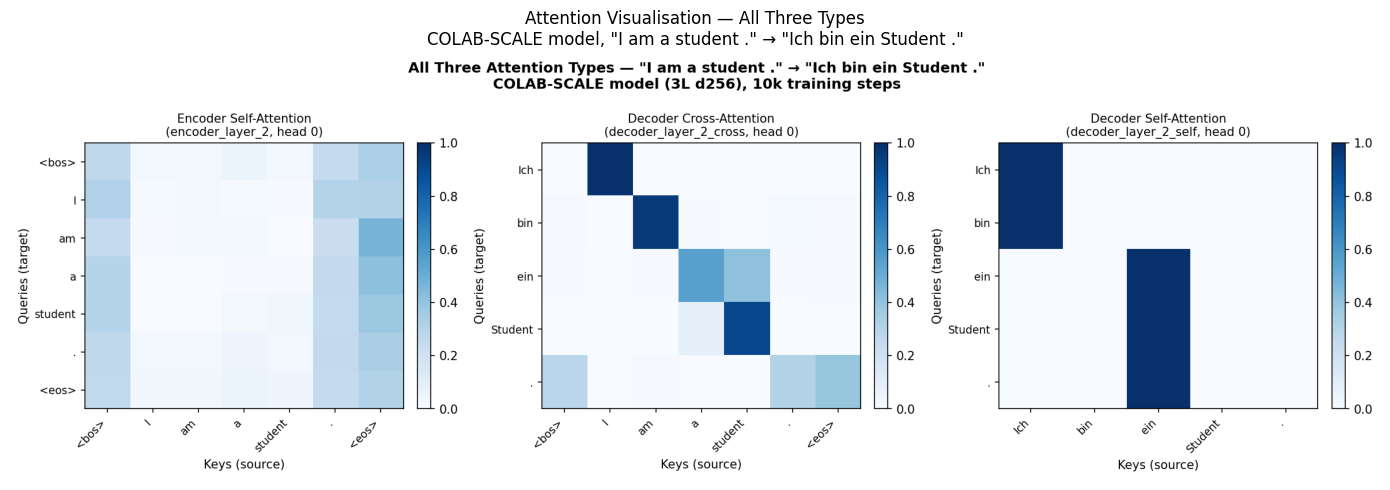

Attention summary displayed from: /content/drive/MyDrive/Transformer_Mine/figures/attention/attention_summary.png


In [15]:
attn_summary_path = os.path.join(
    FIGURES_DIR, 'attention/attention_summary.png'
)

if os.path.exists(attn_summary_path):
    img = plt.imread(attn_summary_path)
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        'Attention Visualisation — All Three Types\n'
        'COLAB-SCALE model, "I am a student ." → "Ich bin ein Student ."',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()
    print(f"Attention summary displayed from: {attn_summary_path}")
else:
    print("Attention summary figure not found.")
    print("Run Phase 16 first.")

#9: Paper Reproduction Assessment

In [16]:

print("=" * 65)
print("PAPER REPRODUCTION ASSESSMENT")
print("=" * 65)
print()

assessments = [
    # Component, reproduced, notes
    ("Scaled dot-product attention",  "YES", "Implemented from scratch, all tests pass"),
    ("Multi-head attention",          "YES", "4 projections, split/merge heads, verified"),
    ("Sinusoidal positional encoding","YES", "Exact formula, relative position property verified"),
    ("Feed-forward network",          "YES", "FFN(x) = ReLU(xW1+b1)W2+b2, exact dimensions"),
    ("Encoder (POST-LN)",             "YES", "6 layers defined, residual+LN verified"),
    ("Decoder (POST-LN)",             "YES", "3 sub-layers, causal mask verified"),
    ("Weight tying",                  "YES", "Decoder embedding = output projection^T"),
    ("Label smoothing (0.1)",         "YES", "Implemented manually with PAD masking"),
    ("LR schedule (warmup)",          "YES", "Exact paper formula, peak at step 4000"),
    ("Adam (beta2=0.98, eps=1e-9)",   "YES", "Paper values used"),
    ("Beam search (k=4, alpha=0.6)",  "YES", "Length penalty implemented"),
    ("BPE tokenization",              "YES", "From scratch, shared vocab"),
    ("Teacher forcing",               "YES", "dec_input/dec_target shift verified"),
    ("Toy overfit test",              "YES", "20/20 exact matches"),
    ("BLEU evaluation",               "YES", "From scratch, verified against known values"),
    ("Attention visualization",       "YES", "All three types, causal mask verified"),
    ("WMT14 EN-DE training",          "NO",  "Requires compute beyond Colab limits"),
    ("100k training steps",           "NO",  "Colab session limit; trained 10k steps"),
    ("27.3 BLEU on newstest2014",     "NO",  "Not evaluated on newstest2014"),
    ("Checkpoint averaging",          "NO",  "Not implemented in this phase"),
    ("Transformer Big",               "NO",  "Out of scope for Colab"),
]

print(f"  {'Component':<40} {'Status':<6} {'Notes'}")
print(f"  {'-'*40} {'-'*6} {'-'*30}")

for component, status, notes in assessments:
    marker = "+" if status == "YES" else "-"
    print(f"  [{marker}] {component:<38} {status:<6} {notes}")

yes_count = sum(1 for _, s, _ in assessments if s == "YES")
no_count  = sum(1 for _, s, _ in assessments if s == "NO")

print()
print(f"  Reproduced     : {yes_count}/{len(assessments)}")
print(f"  Not reproduced : {no_count}/{len(assessments)}")
print()
print("  Summary:")
print("  The Transformer architecture is correctly and completely")
print("  implemented from scratch. All mathematical components match")
print("  the paper. The gap in final BLEU is due to computational")
print("  constraints (data, steps, hardware) not implementation errors.")
print()
print("  This is a reproduction under constrained computational conditions.")

PAPER REPRODUCTION ASSESSMENT

  Component                                Status Notes
  ---------------------------------------- ------ ------------------------------
  [+] Scaled dot-product attention           YES    Implemented from scratch, all tests pass
  [+] Multi-head attention                   YES    4 projections, split/merge heads, verified
  [+] Sinusoidal positional encoding         YES    Exact formula, relative position property verified
  [+] Feed-forward network                   YES    FFN(x) = ReLU(xW1+b1)W2+b2, exact dimensions
  [+] Encoder (POST-LN)                      YES    6 layers defined, residual+LN verified
  [+] Decoder (POST-LN)                      YES    3 sub-layers, causal mask verified
  [+] Weight tying                           YES    Decoder embedding = output projection^T
  [+] Label smoothing (0.1)                  YES    Implemented manually with PAD masking
  [+] LR schedule (warmup)                   YES    Exact paper formula, peak at ste

#10: Final Dashboard

In [18]:
print("FINAL PROJECT DASHBOARD")
print(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("=" * 65)

print("""
PROJECT
  Name     : Reproducing "Attention Is All You Need" in Google Colab
  Paper    : Vaswani et al. 2017
  Platform : Google Colab (single GPU)
  Framework: TensorFlow / Keras

IMPLEMENTATION
  All Transformer components implemented from scratch.
  No pretrained models, no tf.keras.layers.MultiHeadAttention.
  Attention mechanism: scaled dot-product, manual implementation.

ARCHITECTURE (ORIGINAL TRANSFORMER BASE)
  Encoder layers    : 6
  Decoder layers    : 6
  d_model           : 512
  num_heads         : 8
  d_ff              : 2048
  Positional enc    : sinusoidal (fixed)
  Weight tying      : yes
  Normalization     : POST-LN

TRAINING (COLAB-SCALE EXPERIMENT)
  Model             : 3L d256 h4 ff1024
  Dataset           : Tatoeba EN-DE (~80k pairs)
  Steps             : 10,000
  Batch size        : 64
  Optimizer         : Adam (beta2=0.98, eps=1e-9)
  LR schedule       : paper formula (warmup=2000)
  Training time     : ~35 minutes
  Final train loss  : 2.14
  Final val loss    : 2.63
""")

if greedy_bleu is not None:
    print(f"BLEU (COLAB-SCALE, Tatoeba val)")
    print(f"  Greedy          : {greedy_bleu:.2f}")
    print(f"  Beam k=4        : {beam_bleu:.2f}")
    print(f"  Paper (Base)    : 27.3  (WMT14 newstest2014 — not comparable)")



FINAL PROJECT DASHBOARD
Date: 2026-09-30 04:42

PROJECT
  Name     : Reproducing "Attention Is All You Need" in Google Colab
  Paper    : Vaswani et al. 2017
  Platform : Google Colab (single GPU)
  Framework: TensorFlow / Keras

IMPLEMENTATION
  All Transformer components implemented from scratch.
  No pretrained models, no tf.keras.layers.MultiHeadAttention.
  Attention mechanism: scaled dot-product, manual implementation.

ARCHITECTURE (ORIGINAL TRANSFORMER BASE)
  Encoder layers    : 6
  Decoder layers    : 6
  d_model           : 512
  num_heads         : 8
  d_ff              : 2048
  Positional enc    : sinusoidal (fixed)
  Weight tying      : yes
  Normalization     : POST-LN

TRAINING (COLAB-SCALE EXPERIMENT)
  Model             : 3L d256 h4 ff1024
  Dataset           : Tatoeba EN-DE (~80k pairs)
  Steps             : 10,000
  Batch size        : 64
  Optimizer         : Adam (beta2=0.98, eps=1e-9)
  LR schedule       : paper formula (warmup=2000)
  Training time     : ~35 min